# 03 — Canonical Mask Generation

## Purpose

This notebook generates the deterministic synthetic binary damage masks used throughout the controlled painting-restoration experiment.

For every processed painting, five canonical mask types are created:

- `zero_control`
- `scratch_thin`
- `loss_small`
- `loss_large`
- `mixed_damage`

## Method

Mask generation is:

- driven by `config/experiment_50_config.yaml`
- deterministic at global, painting, mask-type and retry levels
- restricted to the recorded painting-content region
- parameterized by damaged-content area targets
- validated against configured area tolerances
- saved as binary grayscale PNG files
- documented through canonical mask metadata
- audited for missing, duplicate, stale, orphaned, incorrectly sized, non-binary or padding-overlapping masks

The mask geometry and generation metadata produced here are reused by later damage creation, restoration, evaluation and robustness-analysis notebooks.

## Canonical outputs

### Generated masks

```text
data/processed/masks/*.png
```

### Mask Metadata

```text
data/processed/metadata/metadata_masks.csv
```

### Generation audit

```text
outputs/03_mask_generation/mask_generation_audit.csv
```

### Figures

```text
outputs/figures/masks/*.png
```

### Reproducibility reports

```text
outputs/reports/mask_generation_metadata.json
outputs/reports/mask_generation_report.md
```

This notebook generates masks only. Canonical damaged images are created in Notebook 04.

In [1]:
from pathlib import Path
import sys

import yaml


def find_project_root(start_path: Path) -> Path:
    """Locate the repository root containing config/ and src/."""
    resolved_start_path = start_path.resolve()

    for candidate_path in [
        resolved_start_path,
        *resolved_start_path.parents,
    ]:
        if (
            (candidate_path / "config").is_dir()
            and (candidate_path / "src").is_dir()
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root containing both "
        "`config/` and `src/`."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

SOURCE_DIR = PROJECT_ROOT / "src"

EXPERIMENT_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)


if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))


print("Project root:", PROJECT_ROOT)
print("Source directory:", SOURCE_DIR)
print("Configuration path:", EXPERIMENT_CONFIG_PATH)

print("\nPath checks")
print("-----------")
print("Source directory exists:", SOURCE_DIR.exists())
print(
    "Configuration file exists:",
    EXPERIMENT_CONFIG_PATH.exists(),
)


if not SOURCE_DIR.exists():
    raise FileNotFoundError(
        f"Source directory not found: {SOURCE_DIR}"
    )

if not EXPERIMENT_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Experiment configuration not found: "
        f"{EXPERIMENT_CONFIG_PATH}"
    )


print("\nNotebook environment initialized successfully.")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Configuration path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml

Path checks
-----------
Source directory exists: True
Configuration file exists: True

Notebook environment initialized successfully.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from restoration_eval.masks import (
    GENERATOR_NAME,
    GENERATOR_VERSION,
    SUPPORTED_MASK_TYPES,
    audit_mask_inventory,
    generate_mask_by_type,
    generate_masks_for_dataset,
    validate_masks,
)


with EXPERIMENT_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as configuration_file:
    experiment_config = yaml.safe_load(configuration_file)


if not isinstance(experiment_config, dict):
    raise ValueError(
        "Configuration must contain a YAML mapping: "
        f"{EXPERIMENT_CONFIG_PATH}"
    )


required_config_sections = [
    "experiment",
    "paths",
    "dataset",
    "preprocessing",
    "masks",
]

missing_config_sections = [
    section_name
    for section_name in required_config_sections
    if section_name not in experiment_config
]

if missing_config_sections:
    raise ValueError(
        "Configuration is missing required sections: "
        f"{missing_config_sections}"
    )


config_version = str(
    experiment_config.get(
        "config_version",
        "unversioned",
    )
)

experiment_config_section = experiment_config["experiment"]
paths_config = experiment_config["paths"]
dataset_config = experiment_config["dataset"]
preprocessing_config = experiment_config["preprocessing"]
mask_config = experiment_config["masks"]


experiment_name = str(
    experiment_config_section.get(
        "name",
        "unnamed_experiment",
    )
)

experiment_version = str(
    experiment_config_section.get(
        "version",
        "unversioned",
    )
)


processed_metadata_dir = (
    PROJECT_ROOT
    / paths_config["processed_metadata_dir"]
)

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)

mask_output_dir = (
    PROJECT_ROOT
    / paths_config["mask_dir"]
)

mask_metadata_path = (
    processed_metadata_dir
    / "metadata_masks.csv"
)

log_output_dir = (
    PROJECT_ROOT
    / paths_config.get(
        "logs_dir",
        "outputs/logs",
    )
)

metrics_output_dir = (
    PROJECT_ROOT
    / paths_config["metrics_dir"]
)

mask_generation_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "03_mask_generation"
)

mask_figure_dir = (
    PROJECT_ROOT
    / paths_config["figures_dir"]
    / "masks"
)

report_output_dir = (
    PROJECT_ROOT
    / paths_config["reports_dir"]
)

mask_generation_audit_path = (
    mask_generation_output_dir
    / "mask_generation_audit.csv"
)

mask_manifest_path = (
    report_output_dir
    / "mask_generation_metadata.json"
)

mask_report_path = (
    report_output_dir
    / "mask_generation_report.md"
)


target_size = int(
    preprocessing_config.get(
        "output_size",
        experiment_config_section.get(
            "image_size",
            768,
        ),
    )
)

expected_painting_count = int(
    dataset_config.get(
        "total_paintings",
        50,
    )
)

generator_name = str(
    mask_config.get(
        "generator_name",
        "canonical_synthetic_damage_masks",
    )
)

generator_version = str(
    mask_config.get(
        "generator_version",
        "unversioned",
    )
)

global_seed = int(
    mask_config.get(
        "base_seed",
        20260630,
    )
)

max_generation_attempts = int(
    mask_config.get(
        "max_generation_attempts",
        30,
    )
)

configured_mask_types = list(
    mask_config.get(
        "mask_types",
        SUPPORTED_MASK_TYPES,
    )
)

configured_mask_specs = mask_config.get(
    "presets",
    {},
)


print("Configuration loaded")
print("--------------------")
print("Config version:", config_version)
print("Experiment:", experiment_name)
print("Experiment version:", experiment_version)
print("Generator:", generator_name)
print("Generator version:", generator_version)
print("Target image size:", target_size)
print("Expected paintings:", expected_painting_count)
print("Global seed:", global_seed)
print(
    "Maximum generation attempts:",
    max_generation_attempts,
)
print("Mask types:", configured_mask_types)

print("\nResolved paths")
print("--------------")
print("Processed metadata:", processed_metadata_path)
print("Mask directory:", mask_output_dir)
print("Mask metadata:", mask_metadata_path)
print(
    "Mask-generation outputs:",
    mask_generation_output_dir,
)
print("Mask figures:", mask_figure_dir)
print("Reports:", report_output_dir)
print("Metrics directory:", metrics_output_dir)
print("Logs directory:", log_output_dir)


if not processed_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed metadata not found: {processed_metadata_path}. "
        "Run Notebook 02 first."
    )

if not configured_mask_types:
    raise ValueError(
        "The configured mask-type list is empty."
    )


missing_mask_specs = [
    mask_type
    for mask_type in configured_mask_types
    if mask_type not in configured_mask_specs
]

if missing_mask_specs:
    raise ValueError(
        "Mask presets are missing for configured mask types: "
        f"{missing_mask_specs}"
    )


if generator_name != GENERATOR_NAME:
    raise ValueError(
        "Configured generator name does not match the implementation: "
        f"config={generator_name!r}, "
        f"implementation={GENERATOR_NAME!r}"
    )

if generator_version != GENERATOR_VERSION:
    raise ValueError(
        "Configured generator version does not match the implementation: "
        f"config={generator_version!r}, "
        f"implementation={GENERATOR_VERSION!r}"
    )


unsupported_configured_mask_types = [
    mask_type
    for mask_type in configured_mask_types
    if mask_type not in SUPPORTED_MASK_TYPES
]

if unsupported_configured_mask_types:
    raise ValueError(
        "Configuration contains unsupported mask types: "
        f"{unsupported_configured_mask_types}"
    )


print("\nMask implementation")
print("-------------------")
print("Implementation generator:", GENERATOR_NAME)
print("Implementation version:", GENERATOR_VERSION)
print(
    "Supported mask types:",
    list(SUPPORTED_MASK_TYPES),
)


processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

print(
    "\nProcessed metadata loaded:",
    processed_metadata_df.shape,
)

display(processed_metadata_df.head())

Configuration loaded
--------------------
Config version: 1.1.0
Experiment: painting_restoration_50_subset
Experiment version: 1.0.0
Generator: canonical_synthetic_damage_masks
Generator version: 2.0.0
Target image size: 768
Expected paintings: 50
Global seed: 20260630
Maximum generation attempts: 30
Mask types: ['zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage']

Resolved paths
--------------
Processed metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks
Mask metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Mask-generation outputs: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\03_mask_generation
Mask figures: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\masks
Reports: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports
Metrics directo

,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


In [3]:
# Validate configuration and processed metadata before mask generation

required_processed_metadata_columns = [
    "painting_id",
    "category",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
    "target_size",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
    "content_area_pixels",
    "canvas_area_pixels",
    "padding_area_pixels",
]


missing_processed_metadata_columns = [
    column_name
    for column_name in required_processed_metadata_columns
    if column_name not in processed_metadata_df.columns
]


if missing_processed_metadata_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_metadata_columns}"
    )


null_painting_id_count = int(
    processed_metadata_df["painting_id"]
    .isna()
    .sum()
)

duplicate_painting_id_rows = processed_metadata_df[
    processed_metadata_df.duplicated(
        subset=["painting_id"],
        keep=False,
    )
].copy()


invalid_processed_size_rows = processed_metadata_df[
    (
        processed_metadata_df["processed_width"]
        != target_size
    )
    | (
        processed_metadata_df["processed_height"]
        != target_size
    )
    | (
        processed_metadata_df["target_size"]
        != target_size
    )
].copy()


valid_content_box_condition = (
    (processed_metadata_df["content_x_min"] >= 0)
    & (processed_metadata_df["content_y_min"] >= 0)
    & (
        processed_metadata_df["content_x_max"]
        <= target_size
    )
    & (
        processed_metadata_df["content_y_max"]
        <= target_size
    )
    & (
        processed_metadata_df["content_x_min"]
        < processed_metadata_df["content_x_max"]
    )
    & (
        processed_metadata_df["content_y_min"]
        < processed_metadata_df["content_y_max"]
    )
    & (processed_metadata_df["content_width"] > 0)
    & (processed_metadata_df["content_height"] > 0)
)


invalid_content_box_rows = processed_metadata_df[
    ~valid_content_box_condition
].copy()


calculated_content_width_series = (
    processed_metadata_df["content_x_max"]
    - processed_metadata_df["content_x_min"]
)

calculated_content_height_series = (
    processed_metadata_df["content_y_max"]
    - processed_metadata_df["content_y_min"]
)

calculated_content_area_series = (
    calculated_content_width_series
    * calculated_content_height_series
)


inconsistent_content_geometry_rows = processed_metadata_df[
    (
        processed_metadata_df["content_width"]
        != calculated_content_width_series
    )
    | (
        processed_metadata_df["content_height"]
        != calculated_content_height_series
    )
    | (
        processed_metadata_df["content_area_pixels"]
        != calculated_content_area_series
    )
].copy()


expected_canvas_area_pixels = target_size * target_size

invalid_canvas_area_rows = processed_metadata_df[
    processed_metadata_df["canvas_area_pixels"]
    != expected_canvas_area_pixels
].copy()


invalid_area_balance_rows = processed_metadata_df[
    (
        processed_metadata_df["content_area_pixels"]
        + processed_metadata_df["padding_area_pixels"]
    )
    != processed_metadata_df["canvas_area_pixels"]
].copy()


expected_mask_count = (
    expected_painting_count
    * len(configured_mask_types)
)


mask_configuration_records = []

for mask_type in configured_mask_types:
    mask_specification = configured_mask_specs[mask_type]

    target_area_percentage = float(
        mask_specification["target_area_pct"]
    )

    minimum_area_percentage = float(
        mask_specification["min_area_pct"]
    )

    maximum_area_percentage = float(
        mask_specification["max_area_pct"]
    )

    mask_configuration_records.append(
        {
            "mask_type": mask_type,
            "target_area_pct": target_area_percentage,
            "min_area_pct": minimum_area_percentage,
            "max_area_pct": maximum_area_percentage,
            "valid_range": (
                0.0
                <= minimum_area_percentage
                <= target_area_percentage
                <= maximum_area_percentage
                <= 100.0
            ),
            "description": mask_specification.get(
                "description",
                "",
            ),
        }
    )


mask_configuration_df = pd.DataFrame(
    mask_configuration_records
)

invalid_mask_specs_df = mask_configuration_df[
    ~mask_configuration_df["valid_range"]
].copy()


print("Processed-metadata gate")
print("-----------------------")
print("Rows:", len(processed_metadata_df))
print(
    "Unique painting IDs:",
    processed_metadata_df["painting_id"].nunique(),
)
print("Expected paintings:", expected_painting_count)
print(
    "Configured mask types:",
    len(configured_mask_types),
)
print("Expected generated masks:", expected_mask_count)

print("\nValidation findings")
print("-------------------")
print(
    "Missing required columns:",
    len(missing_processed_metadata_columns),
)
print("Null painting IDs:", null_painting_id_count)
print(
    "Duplicate painting rows:",
    len(duplicate_painting_id_rows),
)
print(
    "Invalid processed-size rows:",
    len(invalid_processed_size_rows),
)
print(
    "Invalid content-box rows:",
    len(invalid_content_box_rows),
)
print(
    "Inconsistent content-geometry rows:",
    len(inconsistent_content_geometry_rows),
)
print(
    "Invalid canvas-area rows:",
    len(invalid_canvas_area_rows),
)
print(
    "Invalid area-balance rows:",
    len(invalid_area_balance_rows),
)

print("\nConfigured mask presets")
display(mask_configuration_df)


if len(processed_metadata_df) != expected_painting_count:
    raise ValueError(
        f"Expected {expected_painting_count} processed rows, "
        f"found {len(processed_metadata_df)}."
    )

if (
    processed_metadata_df["painting_id"].nunique()
    != expected_painting_count
):
    raise ValueError(
        f"Expected {expected_painting_count} unique painting IDs."
    )

if null_painting_id_count > 0:
    raise ValueError(
        "Processed metadata contains null painting IDs."
    )

if not duplicate_painting_id_rows.empty:
    display(duplicate_painting_id_rows)

    raise ValueError(
        "Processed metadata contains duplicate painting IDs."
    )

if not invalid_processed_size_rows.empty:
    display(invalid_processed_size_rows)

    raise ValueError(
        "Some processed images do not match "
        "the configured target size."
    )

if not invalid_content_box_rows.empty:
    display(invalid_content_box_rows)

    raise ValueError(
        "Some processed-image content boxes are invalid."
    )

if not inconsistent_content_geometry_rows.empty:
    display(inconsistent_content_geometry_rows)

    raise ValueError(
        "Some stored content dimensions or areas do not match "
        "their bounding-box coordinates."
    )

if not invalid_canvas_area_rows.empty:
    display(invalid_canvas_area_rows)

    raise ValueError(
        "Some stored canvas areas do not match "
        "the configured image size."
    )

if not invalid_area_balance_rows.empty:
    display(invalid_area_balance_rows)

    raise ValueError(
        "Some rows do not satisfy "
        "content area + padding area = canvas area."
    )

if not invalid_mask_specs_df.empty:
    display(invalid_mask_specs_df)

    raise ValueError(
        "One or more mask-area presets are invalid."
    )

if configured_mask_types[0] != "zero_control":
    raise ValueError(
        "`zero_control` must be the first configured mask type "
        "to preserve deterministic mask-type ordering."
    )


print(
    "\nConfiguration and processed metadata "
    "passed the generation gate."
)

Processed-metadata gate
-----------------------
Rows: 50
Unique painting IDs: 50
Expected paintings: 50
Configured mask types: 5
Expected generated masks: 250

Validation findings
-------------------
Missing required columns: 0
Null painting IDs: 0
Duplicate painting rows: 0
Invalid processed-size rows: 0
Invalid content-box rows: 0
Inconsistent content-geometry rows: 0
Invalid canvas-area rows: 0
Invalid area-balance rows: 0

Configured mask presets


,mask_type,target_area_pct,min_area_pct,max_area_pct,valid_range,description
0,zero_control,0.0,0.0,0.0,True,No damage. Used to measure unnecessary model c...
1,scratch_thin,2.0,1.0,3.0,True,Thin elongated scratch or crack-like damage.
2,loss_small,4.5,3.0,6.0,True,Small localized irregular missing-paint regions.
3,loss_large,12.5,10.0,15.0,True,Large irregular missing region representing a ...
4,mixed_damage,11.5,8.0,15.0,True,"Combination of scratches, irregular losses, sc..."



Configuration and processed metadata passed the generation gate.


In [4]:
# Verify the imported implementation before generation

mask_generator_information = pd.DataFrame(
    [
        {
            "generator_name": GENERATOR_NAME,
            "generator_version": GENERATOR_VERSION,
            "supported_mask_types": ", ".join(
                SUPPORTED_MASK_TYPES
            ),
            "configured_mask_types": ", ".join(
                configured_mask_types
            ),
        }
    ]
)

generator_configuration_matches = (
    generator_name == GENERERATOR_NAME
    if False else generator_name == GENERATOR_NAME
)

generator_version_matches = (
    generator_version == GENERATOR_VERSION
)

implementation_supported_mask_types = set(
    SUPPORTED_MASK_TYPES
)

configured_mask_type_set = set(
    configured_mask_types
)

unsupported_configured_mask_types = sorted(
    configured_mask_type_set
    - implementation_supported_mask_types
)

missing_supported_mask_types = sorted(
    implementation_supported_mask_types
    - configured_mask_type_set
)

display(mask_generator_information)

print("Generator name:", GENERATOR_NAME)
print("Generator version:", GENERATOR_VERSION)

print("\nVerification")
print("------------")
print(
    "Configured generator matches:",
    generator_configuration_matches,
)
print(
    "Configured version matches:",
    generator_version_matches,
)
print(
    "Unsupported configured types:",
    unsupported_configured_mask_types,
)
print(
    "Supported types not configured:",
    missing_supported_mask_types,
)

if not generator_configuration_matches:
    raise ValueError(
        "Generator implementation mismatch."
    )

if not generator_version_matches:
    raise ValueError(
        "Generator version mismatch."
    )

if unsupported_configured_mask_types:
    raise ValueError(
        "Unsupported configured mask types detected."
    )

print(
    "\nGenerator implementation verified."
)

,generator_name,generator_version,supported_mask_types,configured_mask_types
0,canonical_synthetic_damage_masks,2.0.0,"zero_control, scratch_thin, loss_small, loss_l...","zero_control, scratch_thin, loss_small, loss_l..."


Generator name: canonical_synthetic_damage_masks
Generator version: 2.0.0

Verification
------------
Configured generator matches: True
Configured version matches: True
Unsupported configured types: []
Supported types not configured: []

Generator implementation verified.


In [6]:
# Deterministic one-painting generation test

import shutil


temporary_mask_test_dir = (
    mask_generation_output_dir
    / "tmp_generation_test"
)


if temporary_mask_test_dir.exists():
    shutil.rmtree(
        temporary_mask_test_dir
    )


temporary_mask_test_dir.mkdir(
    parents=True,
    exist_ok=True,
)


test_processed_metadata_df = (
    processed_metadata_df
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .head(1)
    .copy()
)


if len(test_processed_metadata_df) != 1:
    raise ValueError(
        "The deterministic generation test requires "
        "exactly one processed painting."
    )


test_painting_id = str(
    test_processed_metadata_df.iloc[0][
        "painting_id"
    ]
)


test_display_columns = [
    column_name
    for column_name in [
        "painting_id",
        "category",
        "title",
        "processed_filename",
        "processed_path",
        "content_width",
        "content_height",
        "content_area_pixels",
    ]
    if column_name
    in test_processed_metadata_df.columns
]


print("Test painting")
print("-------------")

display(
    test_processed_metadata_df[
        test_display_columns
    ]
)


test_mask_metadata_df = generate_masks_for_dataset(
    metadata=test_processed_metadata_df,
    mask_dir=temporary_mask_test_dir,
    target_size=target_size,
    mask_types=configured_mask_types,
    base_seed=global_seed,
    mask_specs=configured_mask_specs,
    max_attempts=max_generation_attempts,
    generator_name=generator_name,
    generator_version=generator_version,
    config_version=config_version,
    experiment_name=experiment_name,
    experiment_version=experiment_version,
)


expected_test_mask_count = len(
    configured_mask_types
)


print("\nTest generation result")
print("----------------------")
print("Painting ID:", test_painting_id)
print(
    "Generated masks:",
    len(test_mask_metadata_df),
)
print(
    "Expected masks:",
    expected_test_mask_count,
)
print(
    "Test directory:",
    temporary_mask_test_dir,
)


test_summary_columns = [
    "mask_type",
    "target_area_pct",
    "target_area_min_pct",
    "target_area_max_pct",
    "actual_mask_area_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
    "generation_attempts",
    "accepted_attempt",
    "connected_component_count",
    "touches_content_border",
    "padding_overlap_pixels",
    "generation_valid",
    "status",
    "issue",
]


missing_test_summary_columns = [
    column_name
    for column_name in test_summary_columns
    if column_name
    not in test_mask_metadata_df.columns
]


if missing_test_summary_columns:
    raise ValueError(
        "One-painting test metadata is missing columns: "
        f"{missing_test_summary_columns}"
    )


display(
    test_mask_metadata_df[
        test_summary_columns
    ]
)


if (
    len(test_mask_metadata_df)
    != expected_test_mask_count
):
    raise ValueError(
        f"Expected {expected_test_mask_count} test masks, "
        f"generated {len(test_mask_metadata_df)}."
    )


if (
    test_mask_metadata_df["case_id"]
    .nunique()
    != expected_test_mask_count
):
    raise ValueError(
        "The one-painting test produced duplicate case IDs."
    )


if (
    test_mask_metadata_df["mask_id"]
    .nunique()
    != expected_test_mask_count
):
    raise ValueError(
        "The one-painting test produced duplicate mask IDs."
    )


if (
    test_mask_metadata_df["mask_type"]
    .astype(str)
    .tolist()
    != configured_mask_types
):
    raise ValueError(
        "Generated test-mask order does not match "
        "the configured mask-type order."
    )


if not (
    test_mask_metadata_df[
        "generation_valid"
    ]
    .astype(bool)
    .all()
):
    failed_test_mask_rows = (
        test_mask_metadata_df.loc[
            ~test_mask_metadata_df[
                "generation_valid"
            ].astype(bool)
        ]
        .copy()
    )

    display(failed_test_mask_rows)

    raise ValueError(
        "At least one one-painting test mask "
        "failed generation validation."
    )


if (
    test_mask_metadata_df[
        "padding_overlap_pixels"
    ]
    .astype(int)
    .ne(0)
    .any()
):
    raise ValueError(
        "The one-painting test produced damage "
        "inside the padded region."
    )


missing_test_mask_files = [
    Path(mask_path)
    for mask_path in (
        test_mask_metadata_df[
            "mask_path"
        ].astype(str)
    )
    if not Path(mask_path).exists()
]


if missing_test_mask_files:
    raise FileNotFoundError(
        "One or more generated test masks are missing: "
        f"{missing_test_mask_files}"
    )


print(
    "\nOne-painting generation test passed."
)

Test painting
-------------


,painting_id,category,title,processed_filename,processed_path,content_width,content_height,content_area_pixels
0,p001,portrait_figure,Juan de Pareja,p001_clean.png,data/processed/clean/p001_clean.png,663,768,509184



Test generation result
----------------------
Painting ID: p001
Generated masks: 5
Expected masks: 5
Test directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\03_mask_generation\tmp_generation_test


,mask_type,target_area_pct,target_area_min_pct,target_area_max_pct,actual_mask_area_pixels,actual_mask_area_percentage_content,actual_mask_area_percentage_full,generation_attempts,accepted_attempt,connected_component_count,touches_content_border,padding_overlap_pixels,generation_valid,status,issue
0,zero_control,0.0,0.0,0.0,0,0.000000,0.000000,1,1,0,False,0,True,ok,
1,scratch_thin,2.0,1.0,3.0,12058,2.368103,2.044339,1,1,7,True,0,True,ok,
2,loss_small,4.5,3.0,6.0,18239,3.582006,3.092278,1,1,7,False,0,True,ok,
3,loss_large,12.5,10.0,15.0,69018,13.554629,11.701457,3,3,1,False,0,True,ok,
4,mixed_damage,11.5,8.0,15.0,45733,8.981626,7.753669,1,1,10,True,0,True,ok,



One-painting generation test passed.


Deterministic replay comparison
-------------------------------


,mask_type,pixel_arrays_equal,painting_seed_equal,mask_seed_equal,retry_seed_equal,actual_mask_area_pixels_equal,connected_component_count_equal,generation_attempts_equal,accepted_attempt_equal,actual_mask_area_percentage_content_equal,actual_mask_area_percentage_full_equal,replay_passed
0,zero_control,True,True,True,True,True,True,True,True,True,True,True
1,scratch_thin,True,True,True,True,True,True,True,True,True,True,True
2,loss_small,True,True,True,True,True,True,True,True,True,True,True
3,loss_large,True,True,True,True,True,True,True,True,True,True,True
4,mixed_damage,True,True,True,True,True,True,True,True,True,True,True



Deterministic replay passed for all configured mask types.


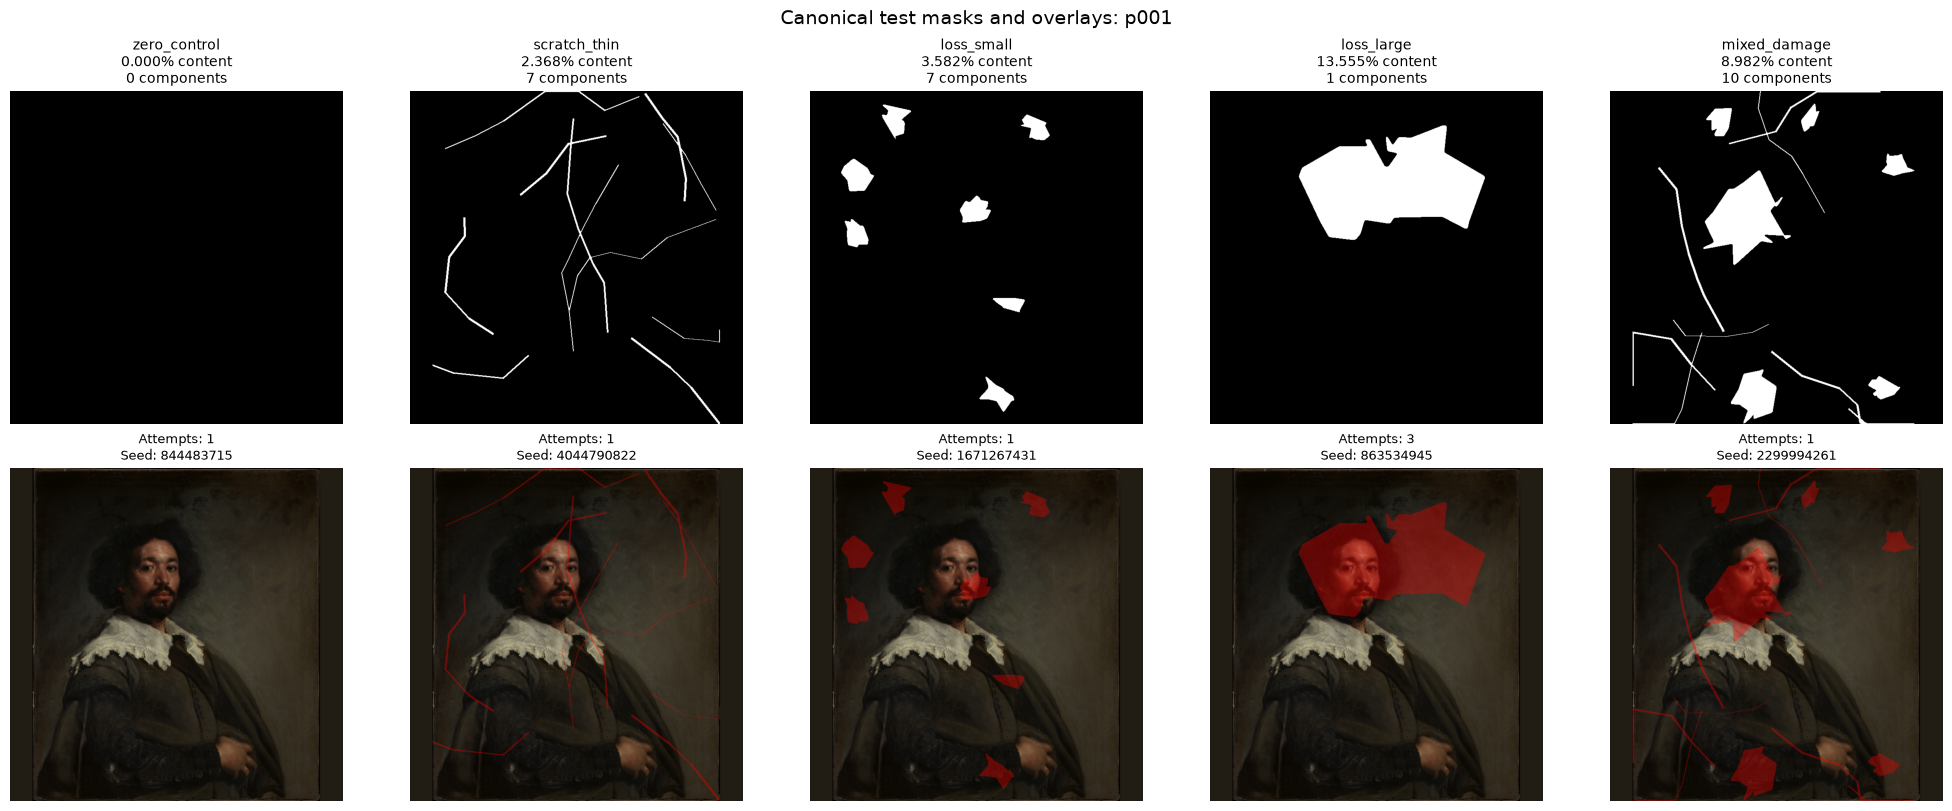


Visual inspection completed.


In [8]:
# Visual inspection and deterministic replay of the one-painting test

test_processed_metadata_row = (
    test_processed_metadata_df.iloc[0]
)


test_processed_image_path = Path(
    str(
        test_processed_metadata_row[
            "processed_path"
        ]
    )
)


if not test_processed_image_path.is_absolute():
    test_processed_image_path = (
        PROJECT_ROOT
        / test_processed_image_path
    )


if not test_processed_image_path.exists():
    raise FileNotFoundError(
        "Processed test image not found: "
        f"{test_processed_image_path}"
    )


with Image.open(
    test_processed_image_path
) as opened_test_image:
    test_clean_image = (
        opened_test_image
        .convert("RGB")
    )
    test_clean_image.load()


if test_clean_image.size != (
    target_size,
    target_size,
):
    raise ValueError(
        "Processed test image has incorrect dimensions: "
        f"{test_clean_image.size}"
    )


test_clean_image_array = np.asarray(
    test_clean_image
)


ordered_test_mask_metadata_df = (
    test_mask_metadata_df
    .set_index("mask_type")
    .reindex(configured_mask_types)
    .reset_index()
)


if (
    ordered_test_mask_metadata_df[
        "case_id"
    ].isna().any()
):
    raise ValueError(
        "One or more configured mask types are missing "
        "from the one-painting test."
    )


temporary_mask_replay_dir = (
    mask_generation_output_dir
    / "tmp_generation_replay"
)


if temporary_mask_replay_dir.exists():
    shutil.rmtree(
        temporary_mask_replay_dir
    )


temporary_mask_replay_dir.mkdir(
    parents=True,
    exist_ok=True,
)


replay_mask_metadata_df = generate_masks_for_dataset(
    metadata=test_processed_metadata_df,
    mask_dir=temporary_mask_replay_dir,
    target_size=target_size,
    mask_types=configured_mask_types,
    base_seed=global_seed,
    mask_specs=configured_mask_specs,
    max_attempts=max_generation_attempts,
    generator_name=generator_name,
    generator_version=generator_version,
    config_version=config_version,
    experiment_name=experiment_name,
    experiment_version=experiment_version,
)


exact_replay_metadata_fields = [
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "actual_mask_area_pixels",
    "connected_component_count",
    "generation_attempts",
    "accepted_attempt",
]


floating_replay_metadata_fields = [
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
]


deterministic_replay_records = []


for mask_type in configured_mask_types:
    original_mask_row = (
        test_mask_metadata_df.loc[
            test_mask_metadata_df[
                "mask_type"
            ]
            == mask_type
        ]
        .iloc[0]
    )

    replay_mask_row = (
        replay_mask_metadata_df.loc[
            replay_mask_metadata_df[
                "mask_type"
            ]
            == mask_type
        ]
        .iloc[0]
    )


    original_mask_path = Path(
        str(
            original_mask_row[
                "mask_path"
            ]
        )
    )

    replay_mask_path = Path(
        str(
            replay_mask_row[
                "mask_path"
            ]
        )
    )


    if not original_mask_path.exists():
        raise FileNotFoundError(
            "Original test mask not found: "
            f"{original_mask_path}"
        )


    if not replay_mask_path.exists():
        raise FileNotFoundError(
            "Replay test mask not found: "
            f"{replay_mask_path}"
        )


    with Image.open(
        original_mask_path
    ) as original_mask_image:
        original_mask_array = np.asarray(
            original_mask_image.convert("L")
        )


    with Image.open(
        replay_mask_path
    ) as replay_mask_image:
        replay_mask_array = np.asarray(
            replay_mask_image.convert("L")
        )


    replay_record = {
        "mask_type": mask_type,
        "pixel_arrays_equal": bool(
            np.array_equal(
                original_mask_array,
                replay_mask_array,
            )
        ),
    }


    for metadata_field in (
        exact_replay_metadata_fields
    ):
        original_value = (
            original_mask_row[
                metadata_field
            ]
        )

        replay_value = (
            replay_mask_row[
                metadata_field
            ]
        )

        if (
            pd.isna(original_value)
            and pd.isna(replay_value)
        ):
            values_equal = True
        else:
            values_equal = bool(
                original_value
                == replay_value
            )

        replay_record[
            f"{metadata_field}_equal"
        ] = values_equal


    for metadata_field in (
        floating_replay_metadata_fields
    ):
        original_value = (
            original_mask_row[
                metadata_field
            ]
        )

        replay_value = (
            replay_mask_row[
                metadata_field
            ]
        )

        if (
            pd.isna(original_value)
            and pd.isna(replay_value)
        ):
            values_equal = True
        elif (
            pd.isna(original_value)
            or pd.isna(replay_value)
        ):
            values_equal = False
        else:
            values_equal = bool(
                np.isclose(
                    float(original_value),
                    float(replay_value),
                    rtol=0.0,
                    atol=1e-10,
                )
            )

        replay_record[
            f"{metadata_field}_equal"
        ] = values_equal


    deterministic_replay_records.append(
        replay_record
    )


deterministic_replay_df = pd.DataFrame(
    deterministic_replay_records
)


deterministic_comparison_columns = [
    column_name
    for column_name
    in deterministic_replay_df.columns
    if column_name.endswith("_equal")
]


deterministic_replay_df[
    "replay_passed"
] = (
    deterministic_replay_df[
        deterministic_comparison_columns
    ]
    .all(axis=1)
)


print("Deterministic replay comparison")
print("-------------------------------")

display(deterministic_replay_df)


failed_replay_rows = (
    deterministic_replay_df.loc[
        ~deterministic_replay_df[
            "replay_passed"
        ]
    ]
    .copy()
)


if not failed_replay_rows.empty:
    failed_replay_details = []

    for _, failed_row in (
        failed_replay_rows.iterrows()
    ):
        failed_checks = [
            column_name
            for column_name
            in deterministic_comparison_columns
            if not bool(
                failed_row[
                    column_name
                ]
            )
        ]

        failed_replay_details.append(
            {
                "mask_type": (
                    failed_row[
                        "mask_type"
                    ]
                ),
                "failed_checks": ", ".join(
                    failed_checks
                ),
            }
        )


    failed_replay_details_df = (
        pd.DataFrame(
            failed_replay_details
        )
    )

    display(
        failed_replay_details_df
    )

    raise RuntimeError(
        "Deterministic replay failed for "
        "one or more mask types."
    )


print(
    "\nDeterministic replay passed for all "
    "configured mask types."
)


preview_figure, preview_axes = plt.subplots(
    2,
    len(configured_mask_types),
    figsize=(
        4 * len(configured_mask_types),
        8,
    ),
    constrained_layout=True,
)


for column_index, mask_row in (
    ordered_test_mask_metadata_df.iterrows()
):
    test_mask_path = Path(
        str(
            mask_row[
                "mask_path"
            ]
        )
    )


    with Image.open(
        test_mask_path
    ) as opened_mask_image:
        test_mask_image = (
            opened_mask_image
            .convert("L")
        )
        test_mask_image.load()


    test_mask_array = np.asarray(
        test_mask_image
    )


    red_overlay_array = (
        test_clean_image_array.copy()
    )

    red_overlay_array[
        test_mask_array > 0
    ] = [
        255,
        0,
        0,
    ]


    blended_overlay_array = (
        0.65
        * test_clean_image_array
        + 0.35
        * red_overlay_array
    ).astype(np.uint8)


    preview_axes[
        0,
        column_index,
    ].imshow(
        test_mask_image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    preview_axes[
        0,
        column_index,
    ].set_title(
        f"{mask_row['mask_type']}\n"
        f"{mask_row['actual_mask_area_percentage_content']:.3f}% content\n"
        f"{mask_row['connected_component_count']} components",
        fontsize=10,
    )

    preview_axes[
        0,
        column_index,
    ].axis("off")


    preview_axes[
        1,
        column_index,
    ].imshow(
        blended_overlay_array
    )

    preview_axes[
        1,
        column_index,
    ].set_title(
        f"Attempts: "
        f"{mask_row['generation_attempts']}\n"
        f"Seed: {mask_row['mask_seed']}",
        fontsize=9,
    )

    preview_axes[
        1,
        column_index,
    ].axis("off")


preview_figure.suptitle(
    "Canonical test masks and overlays: "
    f"{test_painting_id}",
    fontsize=14,
)


plt.show()
plt.close(preview_figure)


print("\nVisual inspection completed.")

In [9]:
# Generate the complete canonical mask set

mask_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

mask_metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

mask_generation_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)


expected_mask_filenames = {
    (
        f"{painting_id}_"
        f"{mask_type}_mask.png"
    )
    for painting_id in (
        processed_metadata_df[
            "painting_id"
        ]
        .astype(str)
        .tolist()
    )
    for mask_type in configured_mask_types
}


existing_mask_files_before_generation = sorted(
    mask_path
    for mask_path
    in mask_output_dir.glob("*.png")
    if mask_path.is_file()
)


existing_mask_filenames_before_generation = {
    mask_path.name
    for mask_path
    in existing_mask_files_before_generation
}


unexpected_mask_filenames_before_generation = sorted(
    existing_mask_filenames_before_generation
    - expected_mask_filenames
)


missing_mask_filenames_before_generation = sorted(
    expected_mask_filenames
    - existing_mask_filenames_before_generation
)


print("Pre-generation inventory")
print("------------------------")
print(
    "Expected canonical filenames:",
    len(expected_mask_filenames),
)
print(
    "Existing PNG files:",
    len(
        existing_mask_files_before_generation
    ),
)
print(
    "Unexpected existing PNG files:",
    len(
        unexpected_mask_filenames_before_generation
    ),
)
print(
    "Missing expected files before generation:",
    len(
        missing_mask_filenames_before_generation
    ),
)


if unexpected_mask_filenames_before_generation:
    print(
        "\nUnexpected existing files were detected. "
        "They will not be deleted automatically."
    )

    display(
        pd.DataFrame(
            {
                "mask_filename": (
                    unexpected_mask_filenames_before_generation
                ),
                "pre_generation_status": (
                    "unexpected_or_stale_candidate"
                ),
            }
        )
    )


mask_metadata_df = generate_masks_for_dataset(
    metadata=processed_metadata_df,
    mask_dir=mask_output_dir,
    target_size=target_size,
    mask_types=configured_mask_types,
    base_seed=global_seed,
    mask_specs=configured_mask_specs,
    max_attempts=max_generation_attempts,
    generator_name=generator_name,
    generator_version=generator_version,
    config_version=config_version,
    experiment_name=experiment_name,
    experiment_version=experiment_version,
)


expected_mask_count = (
    len(processed_metadata_df)
    * len(configured_mask_types)
)


print("\nCanonical generation result")
print("---------------------------")
print(
    "Generated metadata rows:",
    len(mask_metadata_df),
)
print("Expected rows:", expected_mask_count)
print(
    "Unique paintings:",
    mask_metadata_df[
        "painting_id"
    ].nunique(),
)
print(
    "Unique cases:",
    mask_metadata_df[
        "case_id"
    ].nunique(),
)
print(
    "Unique mask IDs:",
    mask_metadata_df[
        "mask_id"
    ].nunique(),
)
print("Mask directory:", mask_output_dir)


print("\nMask-type counts")

display(
    mask_metadata_df[
        "mask_type"
    ]
    .value_counts()
    .reindex(
        configured_mask_types,
        fill_value=0,
    )
    .rename_axis("mask_type")
    .reset_index(name="count")
)


print("\nGeneration-status counts")

display(
    mask_metadata_df[
        "generation_status"
    ]
    .value_counts(dropna=False)
    .rename_axis("generation_status")
    .reset_index(name="count")
)


print("\nCanonical status counts")

display(
    mask_metadata_df[
        "status"
    ]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)


print("\nIssue counts")

display(
    mask_metadata_df[
        "issue"
    ]
    .replace("", "ok")
    .value_counts(dropna=False)
    .rename_axis("issue")
    .reset_index(name="count")
)


generation_preview_columns = [
    "case_id",
    "mask_type",
    "generator_version",
    "global_seed",
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "target_area_pct",
    "actual_mask_area_percentage_content",
    "generation_attempts",
    "connected_component_count",
    "bbox_fill_ratio",
    "padding_overlap_pixels",
    "generation_valid",
]


missing_generation_preview_columns = [
    column_name
    for column_name
    in generation_preview_columns
    if column_name
    not in mask_metadata_df.columns
]


if missing_generation_preview_columns:
    raise ValueError(
        "Generated mask metadata is missing preview columns: "
        f"{missing_generation_preview_columns}"
    )


display(
    mask_metadata_df[
        generation_preview_columns
    ].head(10)
)


if len(mask_metadata_df) != expected_mask_count:
    raise ValueError(
        f"Expected {expected_mask_count} mask records, "
        f"generated {len(mask_metadata_df)}."
    )


if (
    mask_metadata_df["case_id"]
    .nunique()
    != expected_mask_count
):
    raise ValueError(
        "Generated mask metadata contains "
        "duplicate case IDs."
    )


if (
    mask_metadata_df["mask_id"]
    .nunique()
    != expected_mask_count
):
    raise ValueError(
        "Generated mask metadata contains "
        "duplicate mask IDs."
    )


if (
    mask_metadata_df["mask_filename"]
    .nunique()
    != expected_mask_count
):
    raise ValueError(
        "Generated mask metadata contains "
        "duplicate filenames."
    )


if not (
    mask_metadata_df[
        "generation_valid"
    ]
    .astype(bool)
    .all()
):
    failed_generation_rows = (
        mask_metadata_df.loc[
            ~mask_metadata_df[
                "generation_valid"
            ].astype(bool)
        ]
        .copy()
    )

    display(failed_generation_rows)

    raise ValueError(
        "At least one generated mask failed "
        "canonical generation checks."
    )


print(
    "\nCanonical mask generation completed successfully."
)

Pre-generation inventory
------------------------
Expected canonical filenames: 250
Existing PNG files: 0
Unexpected existing PNG files: 0
Missing expected files before generation: 250

Canonical generation result
---------------------------
Generated metadata rows: 250
Expected rows: 250
Unique paintings: 50
Unique cases: 250
Unique mask IDs: 250
Mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks

Mask-type counts


,mask_type,count
0,zero_control,50
1,scratch_thin,50
2,loss_small,50
3,loss_large,50
4,mixed_damage,50



Generation-status counts


,generation_status,count
0,ok,250



Canonical status counts


,status,count
0,ok,250



Issue counts


,issue,count
0,ok,250


,case_id,mask_type,generator_version,global_seed,painting_seed,mask_seed,retry_seed,target_area_pct,actual_mask_area_percentage_content,generation_attempts,connected_component_count,bbox_fill_ratio,padding_overlap_pixels,generation_valid
0,p001_zero_control,zero_control,2.0.0,20260630,1049792242,844483715,887186148,0.0,0.000000,1,0,0.000000,0,True
1,p001_scratch_thin,scratch_thin,2.0.0,20260630,1049792242,4044790822,2328332586,2.0,2.368103,1,7,0.023681,0,True
2,p001_loss_small,loss_small,2.0.0,20260630,1049792242,1671267431,4093361246,4.5,3.582006,1,7,0.053482,0,True
3,p001_loss_large,loss_large,2.0.0,20260630,1049792242,863534945,465719629,12.5,13.554629,3,1,0.609398,0,True
4,p001_mixed_damage,mixed_damage,2.0.0,20260630,1049792242,2299994261,3833033610,11.5,8.981626,1,10,0.091613,0,True
5,p002_zero_control,zero_control,2.0.0,20260630,2652208543,3431267103,796384237,0.0,0.000000,1,0,0.000000,0,True
6,p002_scratch_thin,scratch_thin,2.0.0,20260630,2652208543,339112385,4187836088,2.0,2.783674,2,4,0.028851,0,True
7,p002_loss_small,loss_small,2.0.0,20260630,2652208543,1946636804,991765720,4.5,5.444970,1,7,0.088312,0,True
8,p002_loss_large,loss_large,2.0.0,20260630,2652208543,3331775940,835546425,12.5,10.857171,5,1,0.597742,0,True
9,p002_mixed_damage,mixed_damage,2.0.0,20260630,2652208543,747555413,1598298252,11.5,10.018212,1,4,0.100182,0,True



Canonical mask generation completed successfully.


In [10]:
# Save and verify canonical mask metadata

mask_metadata_df.to_csv(
    mask_metadata_path,
    index=False,
)


print("Mask metadata saved")
print("-------------------")
print("Path:", mask_metadata_path)
print("Exists:", mask_metadata_path.exists())
print("Rows:", len(mask_metadata_df))
print(
    "Columns:",
    len(mask_metadata_df.columns),
)
print(
    "File size:",
    mask_metadata_path.stat().st_size,
    "bytes",
)


reloaded_mask_metadata_df = pd.read_csv(
    mask_metadata_path
)


print("\nReload verification")
print("-------------------")
print(
    "Reloaded shape:",
    reloaded_mask_metadata_df.shape,
)


required_mask_metadata_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_type_index",
    "mask_filename",
    "mask_path",
    "generator_name",
    "generator_version",
    "config_version",
    "experiment_name",
    "experiment_version",
    "global_seed",
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "painting_index",
    "target_area_pct",
    "target_area_min_pct",
    "target_area_max_pct",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "canvas_area_pixels",
    "content_area_pixels",
    "padding_area_pixels",
    "actual_mask_area_pixels",
    "damaged_content_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
    "padding_overlap_pixels",
    "bbox_x_min",
    "bbox_y_min",
    "bbox_x_max",
    "bbox_y_max",
    "bbox_width",
    "bbox_height",
    "bbox_area_pixels",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "connected_component_count",
    "largest_component_pixels",
    "smallest_component_pixels",
    "mean_component_pixels",
    "median_component_pixels",
    "component_area_std_pixels",
    "largest_component_fraction",
    "component_density_per_100k_content_pixels",
    "mean_component_aspect_ratio",
    "maximum_component_aspect_ratio",
    "touches_content_border",
    "minimum_distance_to_content_border_pixels",
    "generation_attempts",
    "accepted_attempt",
    "area_distance_to_target_pct",
    "area_distance_to_allowed_range_pct",
    "generation_status",
    "unique_pixel_values",
    "binary_values_valid",
    "zero_control_rule_valid",
    "content_only_valid",
    "area_within_target_tolerance",
    "generation_valid",
    "status",
    "issue",
]


missing_mask_metadata_columns = [
    column_name
    for column_name
    in required_mask_metadata_columns
    if column_name
    not in reloaded_mask_metadata_df.columns
]


if missing_mask_metadata_columns:
    raise ValueError(
        "Reloaded mask metadata is missing required columns: "
        f"{missing_mask_metadata_columns}"
    )


if (
    reloaded_mask_metadata_df.shape
    != mask_metadata_df.shape
):
    raise ValueError(
        "Reloaded mask metadata shape does not match "
        "the in-memory metadata."
    )


case_ids_preserved = (
    reloaded_mask_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
    == mask_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


mask_filenames_preserved = (
    reloaded_mask_metadata_df[
        "mask_filename"
    ]
    .astype(str)
    .tolist()
    == mask_metadata_df[
        "mask_filename"
    ]
    .astype(str)
    .tolist()
)


print(
    "Case IDs preserved:",
    case_ids_preserved,
)
print(
    "Mask filenames preserved:",
    mask_filenames_preserved,
)


if not case_ids_preserved:
    raise ValueError(
        "Case-ID ordering changed after metadata reload."
    )


if not mask_filenames_preserved:
    raise ValueError(
        "Mask filenames changed after metadata reload."
    )


if (
    reloaded_mask_metadata_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Reloaded metadata contains duplicate case IDs."
    )


if (
    reloaded_mask_metadata_df[
        "mask_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Reloaded metadata contains duplicate mask IDs."
    )


if (
    reloaded_mask_metadata_df[
        "mask_filename"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Reloaded metadata contains duplicate mask filenames."
    )


if (
    reloaded_mask_metadata_df[
        "generator_version"
    ]
    .astype(str)
    .ne(generator_version)
    .any()
):
    raise ValueError(
        "Reloaded metadata contains an unexpected "
        "generator version."
    )


mask_metadata_df = (
    reloaded_mask_metadata_df.copy()
)


print(
    "\nCanonical metadata save/reload "
    "verification passed."
)

display(mask_metadata_df.head())

Mask metadata saved
-------------------
Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Exists: True
Rows: 250
Columns: 66
File size: 139074 bytes

Reload verification
-------------------
Reloaded shape: (250, 66)
Case IDs preserved: True
Mask filenames preserved: True

Canonical metadata save/reload verification passed.


,case_id,painting_id,mask_id,mask_type,mask_type_index,mask_filename,mask_path,generator_name,generator_version,config_version,...,area_distance_to_allowed_range_pct,area_within_target_tolerance,generation_status,unique_pixel_values,binary_values_valid,zero_control_rule_valid,content_only_valid,generation_valid,status,issue
0,p001_zero_control,p001,p001_zero_control,zero_control,0,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0,True,True,True,True,ok,NaN
1,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,1,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
2,p001_loss_small,p001,p001_loss_small,loss_small,2,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
3,p001_loss_large,p001,p001_loss_large,loss_large,3,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
4,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,4,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN


In [11]:
# Save and verify canonical mask metadata

mask_metadata_df.to_csv(
    mask_metadata_path,
    index=False,
)


print("Mask metadata saved")
print("-------------------")
print("Path:", mask_metadata_path)
print("Exists:", mask_metadata_path.exists())
print("Rows:", len(mask_metadata_df))
print(
    "Columns:",
    len(mask_metadata_df.columns),
)
print(
    "File size:",
    mask_metadata_path.stat().st_size,
    "bytes",
)


reloaded_mask_metadata_df = pd.read_csv(
    mask_metadata_path
)


print("\nReload verification")
print("-------------------")
print(
    "Reloaded shape:",
    reloaded_mask_metadata_df.shape,
)


required_mask_metadata_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_type_index",
    "mask_filename",
    "mask_path",
    "generator_name",
    "generator_version",
    "config_version",
    "experiment_name",
    "experiment_version",
    "global_seed",
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "painting_index",
    "target_area_pct",
    "target_area_min_pct",
    "target_area_max_pct",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "canvas_area_pixels",
    "content_area_pixels",
    "padding_area_pixels",
    "actual_mask_area_pixels",
    "damaged_content_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
    "padding_overlap_pixels",
    "bbox_x_min",
    "bbox_y_min",
    "bbox_x_max",
    "bbox_y_max",
    "bbox_width",
    "bbox_height",
    "bbox_area_pixels",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "connected_component_count",
    "largest_component_pixels",
    "smallest_component_pixels",
    "mean_component_pixels",
    "median_component_pixels",
    "component_area_std_pixels",
    "largest_component_fraction",
    "component_density_per_100k_content_pixels",
    "mean_component_aspect_ratio",
    "maximum_component_aspect_ratio",
    "touches_content_border",
    "minimum_distance_to_content_border_pixels",
    "generation_attempts",
    "accepted_attempt",
    "area_distance_to_target_pct",
    "area_distance_to_allowed_range_pct",
    "generation_status",
    "unique_pixel_values",
    "binary_values_valid",
    "zero_control_rule_valid",
    "content_only_valid",
    "area_within_target_tolerance",
    "generation_valid",
    "status",
    "issue",
]


missing_mask_metadata_columns = [
    column_name
    for column_name
    in required_mask_metadata_columns
    if column_name
    not in reloaded_mask_metadata_df.columns
]


if missing_mask_metadata_columns:
    raise ValueError(
        "Reloaded mask metadata is missing required columns: "
        f"{missing_mask_metadata_columns}"
    )


if (
    reloaded_mask_metadata_df.shape
    != mask_metadata_df.shape
):
    raise ValueError(
        "Reloaded mask metadata shape does not match "
        "the in-memory metadata."
    )


case_ids_preserved = (
    reloaded_mask_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
    == mask_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


mask_filenames_preserved = (
    reloaded_mask_metadata_df[
        "mask_filename"
    ]
    .astype(str)
    .tolist()
    == mask_metadata_df[
        "mask_filename"
    ]
    .astype(str)
    .tolist()
)


print(
    "Case IDs preserved:",
    case_ids_preserved,
)
print(
    "Mask filenames preserved:",
    mask_filenames_preserved,
)


if not case_ids_preserved:
    raise ValueError(
        "Case-ID ordering changed after metadata reload."
    )


if not mask_filenames_preserved:
    raise ValueError(
        "Mask filenames changed after metadata reload."
    )


if (
    reloaded_mask_metadata_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Reloaded metadata contains duplicate case IDs."
    )


if (
    reloaded_mask_metadata_df[
        "mask_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Reloaded metadata contains duplicate mask IDs."
    )


if (
    reloaded_mask_metadata_df[
        "mask_filename"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Reloaded metadata contains duplicate mask filenames."
    )


if (
    reloaded_mask_metadata_df[
        "generator_version"
    ]
    .astype(str)
    .ne(generator_version)
    .any()
):
    raise ValueError(
        "Reloaded metadata contains an unexpected "
        "generator version."
    )


mask_metadata_df = (
    reloaded_mask_metadata_df.copy()
)


print(
    "\nCanonical metadata save/reload "
    "verification passed."
)

display(mask_metadata_df.head())

Mask metadata saved
-------------------
Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Exists: True
Rows: 250
Columns: 66
File size: 139074 bytes

Reload verification
-------------------
Reloaded shape: (250, 66)
Case IDs preserved: True
Mask filenames preserved: True

Canonical metadata save/reload verification passed.


,case_id,painting_id,mask_id,mask_type,mask_type_index,mask_filename,mask_path,generator_name,generator_version,config_version,...,area_distance_to_allowed_range_pct,area_within_target_tolerance,generation_status,unique_pixel_values,binary_values_valid,zero_control_rule_valid,content_only_valid,generation_valid,status,issue
0,p001_zero_control,p001,p001_zero_control,zero_control,0,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0,True,True,True,True,ok,NaN
1,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,1,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
2,p001_loss_small,p001,p001_loss_small,loss_small,2,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
3,p001_loss_large,p001,p001_loss_large,loss_large,3,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
4,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,4,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN


In [12]:
# Validate canonical saved mask files

mask_validation_df = validate_masks(
    mask_metadata=mask_metadata_df,
    target_size=target_size,
)

print("Saved-mask validation")
print("---------------------")
print(f"Rows checked: {len(mask_validation_df)}")

validation_summary = pd.DataFrame(
    {
        "metric": [
            "Files present",
            "Readable",
            "Validation passed",
            "Validation failed",
        ],
        "value": [
            int(mask_validation_df["file_exists"].sum()),
            int(mask_validation_df["readable"].sum()),
            int(mask_validation_df["validation_passed"].sum()),
            int((~mask_validation_df["validation_passed"]).sum()),
        ],
    }
)

display(validation_summary)

display(
    mask_validation_df["issue"]
    .replace("", "ok")
    .value_counts(dropna=False)
    .rename_axis("issue")
    .reset_index(name="count")
)

failed_validation_df = mask_validation_df.loc[
    ~mask_validation_df["validation_passed"]
].copy()

if not failed_validation_df.empty:
    display(failed_validation_df)
    raise RuntimeError(
        "Saved-mask validation failed."
    )

expected_mask_count = (
    len(processed_metadata_df)
    * len(configured_mask_types)
)

if len(mask_validation_df) != expected_mask_count:
    raise RuntimeError(
        "Validation row count mismatch."
    )

print(
    "\nAll generated masks passed validation."
)

Saved-mask validation
---------------------
Rows checked: 250


,metric,value
0,Files present,250
1,Readable,250
2,Validation passed,250
3,Validation failed,0


,issue,count
0,ok,250



All generated masks passed validation.


In [13]:
# Inventory and completeness audit

expected_mask_count = (
    len(processed_metadata_df)
    * len(configured_mask_types)
)

mask_files = sorted(
    mask_output_dir.glob("*.png")
)

inventory_audit_df = pd.DataFrame(
    {
        "metric": [
            "Processed paintings",
            "Configured mask types",
            "Expected masks",
            "Metadata rows",
            "PNG files",
            "Unique case IDs",
            "Unique mask IDs",
            "Unique filenames",
        ],
        "value": [
            len(processed_metadata_df),
            len(configured_mask_types),
            expected_mask_count,
            len(mask_metadata_df),
            len(mask_files),
            mask_metadata_df["case_id"].nunique(),
            mask_metadata_df["mask_id"].nunique(),
            mask_metadata_df["mask_filename"].nunique(),
        ],
    }
)

display(inventory_audit_df)

assert len(mask_metadata_df) == expected_mask_count
assert len(mask_files) == expected_mask_count
assert mask_metadata_df["case_id"].nunique() == expected_mask_count
assert mask_metadata_df["mask_id"].nunique() == expected_mask_count
assert (
    mask_metadata_df["mask_filename"].nunique()
    == expected_mask_count
)

mask_generation_audit_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

inventory_audit_df.to_csv(
    mask_generation_audit_path,
    index=False,
)

print(
    "\nInventory audit passed."
)

,metric,value
0,Processed paintings,50
1,Configured mask types,5
2,Expected masks,250
3,Metadata rows,250
4,PNG files,250
5,Unique case IDs,250
6,Unique mask IDs,250
7,Unique filenames,250



Inventory audit passed.


In [14]:
# Create display-only mask-generation summary tables

required_summary_columns = [
    "mask_type",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
    "actual_mask_area_pixels",
    "connected_component_count",
    "bbox_fill_ratio",
    "largest_component_fraction",
    "touches_content_border",
    "generation_attempts",
    "mean_component_aspect_ratio",
    "maximum_component_aspect_ratio",
]


missing_summary_columns = [
    column_name
    for column_name in required_summary_columns
    if column_name not in mask_metadata_df.columns
]


if missing_summary_columns:
    raise ValueError(
        "Mask metadata is missing columns required "
        "for summary generation: "
        f"{missing_summary_columns}"
    )


mask_type_count_summary_df = (
    mask_metadata_df["mask_type"]
    .value_counts()
    .reindex(
        configured_mask_types,
        fill_value=0,
    )
    .rename_axis("mask_type")
    .reset_index(name="case_count")
)


mask_area_summary_df = (
    mask_metadata_df
    .groupby(
        "mask_type",
        observed=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        mean_area_percentage_content=(
            "actual_mask_area_percentage_content",
            "mean",
        ),
        standard_deviation_area_percentage_content=(
            "actual_mask_area_percentage_content",
            "std",
        ),
        minimum_area_percentage_content=(
            "actual_mask_area_percentage_content",
            "min",
        ),
        median_area_percentage_content=(
            "actual_mask_area_percentage_content",
            "median",
        ),
        maximum_area_percentage_content=(
            "actual_mask_area_percentage_content",
            "max",
        ),
        mean_area_percentage_full=(
            "actual_mask_area_percentage_full",
            "mean",
        ),
        mean_area_pixels=(
            "actual_mask_area_pixels",
            "mean",
        ),
    )
    .reindex(configured_mask_types)
    .reset_index()
)


mask_component_summary_df = (
    mask_metadata_df
    .groupby(
        "mask_type",
        observed=True,
    )
    .agg(
        mean_connected_component_count=(
            "connected_component_count",
            "mean",
        ),
        median_connected_component_count=(
            "connected_component_count",
            "median",
        ),
        maximum_connected_component_count=(
            "connected_component_count",
            "max",
        ),
        mean_largest_component_fraction=(
            "largest_component_fraction",
            "mean",
        ),
        mean_component_aspect_ratio=(
            "mean_component_aspect_ratio",
            "mean",
        ),
        mean_maximum_component_aspect_ratio=(
            "maximum_component_aspect_ratio",
            "mean",
        ),
    )
    .reindex(configured_mask_types)
    .reset_index()
)


mask_bbox_summary_df = (
    mask_metadata_df
    .groupby(
        "mask_type",
        observed=True,
    )
    .agg(
        mean_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "mean",
        ),
        median_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "median",
        ),
        minimum_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "min",
        ),
        maximum_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "max",
        ),
    )
    .reindex(configured_mask_types)
    .reset_index()
)


mask_generation_attempt_summary_df = (
    mask_metadata_df
    .groupby(
        "mask_type",
        observed=True,
    )
    .agg(
        mean_generation_attempts=(
            "generation_attempts",
            "mean",
        ),
        median_generation_attempts=(
            "generation_attempts",
            "median",
        ),
        maximum_generation_attempts=(
            "generation_attempts",
            "max",
        ),
        cases_requiring_retry=(
            "generation_attempts",
            lambda series: int(
                (series.astype(int) > 1).sum()
            ),
        ),
    )
    .reindex(configured_mask_types)
    .reset_index()
)


mask_border_summary_df = (
    mask_metadata_df
    .assign(
        touches_content_border=(
            mask_metadata_df[
                "touches_content_border"
            ].astype(bool)
        )
    )
    .groupby(
        "mask_type",
        observed=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        border_touch_count=(
            "touches_content_border",
            "sum",
        ),
        border_touch_percentage=(
            "touches_content_border",
            lambda series: (
                100.0
                * series.astype(bool).mean()
            ),
        ),
    )
    .reindex(configured_mask_types)
    .reset_index()
)


mask_validation_summary_df = pd.DataFrame(
    [
        {
            "validation_check": (
                "Expected metadata rows"
            ),
            "value": len(mask_metadata_df),
            "expected": expected_mask_count,
            "passed": (
                len(mask_metadata_df)
                == expected_mask_count
            ),
        },
        {
            "validation_check": (
                "Unique case IDs"
            ),
            "value": (
                mask_metadata_df[
                    "case_id"
                ].nunique()
            ),
            "expected": expected_mask_count,
            "passed": (
                mask_metadata_df[
                    "case_id"
                ].nunique()
                == expected_mask_count
            ),
        },
        {
            "validation_check": (
                "Unique mask IDs"
            ),
            "value": (
                mask_metadata_df[
                    "mask_id"
                ].nunique()
            ),
            "expected": expected_mask_count,
            "passed": (
                mask_metadata_df[
                    "mask_id"
                ].nunique()
                == expected_mask_count
            ),
        },
        {
            "validation_check": (
                "Valid generations"
            ),
            "value": int(
                mask_metadata_df[
                    "generation_valid"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": expected_mask_count,
            "passed": bool(
                mask_metadata_df[
                    "generation_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "validation_check": (
                "Zero padding overlap"
            ),
            "value": int(
                mask_metadata_df[
                    "padding_overlap_pixels"
                ]
                .astype(int)
                .eq(0)
                .sum()
            ),
            "expected": expected_mask_count,
            "passed": bool(
                mask_metadata_df[
                    "padding_overlap_pixels"
                ]
                .astype(int)
                .eq(0)
                .all()
            ),
        },
        {
            "validation_check": (
                "Saved-file validation passes"
            ),
            "value": int(
                mask_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": expected_mask_count,
            "passed": bool(
                mask_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Mask-type counts")
print("----------------")

display(mask_type_count_summary_df)


print("\nMask-area summary")
print("-----------------")

display(
    mask_area_summary_df.round(4)
)


print("\nConnected-component summary")
print("---------------------------")

display(
    mask_component_summary_df.round(4)
)


print("\nBounding-box summary")
print("--------------------")

display(
    mask_bbox_summary_df.round(4)
)


print("\nGeneration-attempt summary")
print("--------------------------")

display(
    mask_generation_attempt_summary_df.round(4)
)


print("\nContent-border summary")
print("----------------------")

display(
    mask_border_summary_df.round(4)
)


print("\nValidation summary")
print("------------------")

display(mask_validation_summary_df)


if not (
    mask_validation_summary_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    failed_summary_checks_df = (
        mask_validation_summary_df.loc[
            ~mask_validation_summary_df[
                "passed"
            ].astype(bool)
        ]
        .copy()
    )

    display(failed_summary_checks_df)

    raise RuntimeError(
        "One or more mask-generation "
        "summary checks failed."
    )


print(
    "\nMask-generation summary statistics "
    "completed successfully."
)

Mask-type counts
----------------


,mask_type,case_count
0,zero_control,50
1,scratch_thin,50
2,loss_small,50
3,loss_large,50
4,mixed_damage,50



Mask-area summary
-----------------


,mask_type,case_count,mean_area_percentage_content,standard_deviation_area_percentage_content,minimum_area_percentage_content,median_area_percentage_content,maximum_area_percentage_content,mean_area_percentage_full,mean_area_pixels
0,zero_control,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00
1,scratch_thin,50,2.1363,0.4984,1.1081,2.1380,2.9782,1.6301,9614.46
2,loss_small,50,4.0246,0.6469,3.0869,3.9334,5.5021,3.0815,18175.36
3,loss_large,50,12.3288,1.3686,10.1506,12.2767,14.9143,9.5345,56236.98
4,mixed_damage,50,9.6600,1.3449,8.0840,9.3117,13.2845,7.3615,43420.00



Connected-component summary
---------------------------


...


Content-border summary
----------------------


,mask_type,case_count,border_touch_count,border_touch_percentage
0,zero_control,50,0,0.0
1,scratch_thin,50,50,100.0
2,loss_small,50,0,0.0
3,loss_large,50,0,0.0
4,mixed_damage,50,50,100.0



Validation summary
------------------


,validation_check,value,expected,passed
0,Expected metadata rows,250,250,True
1,Unique case IDs,250,250,True
2,Unique mask IDs,250,250,True
3,Valid generations,250,250,True
4,Zero padding overlap,250,250,True
5,Saved-file validation passes,250,250,True



Mask-generation summary statistics completed successfully.


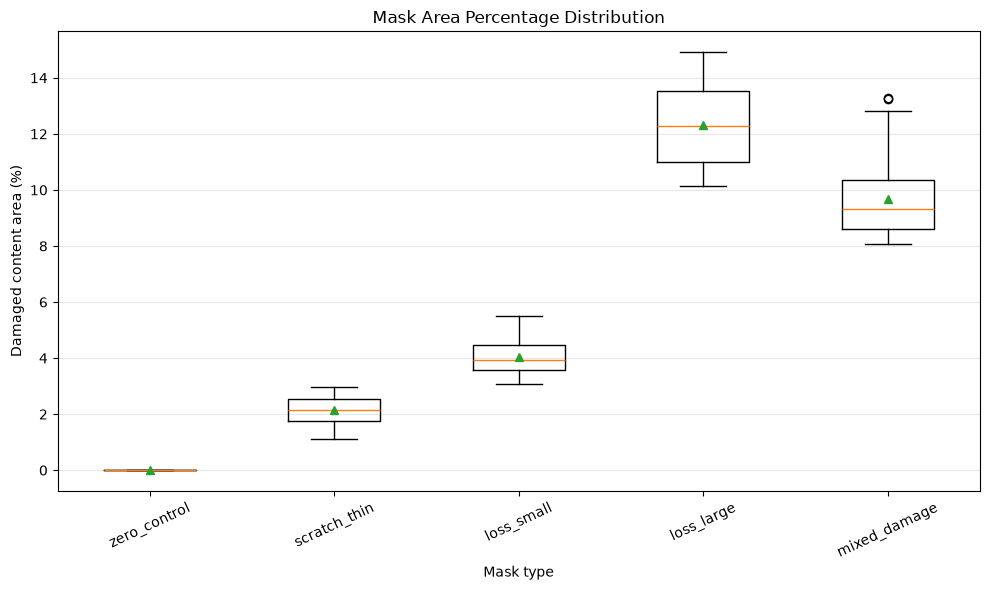

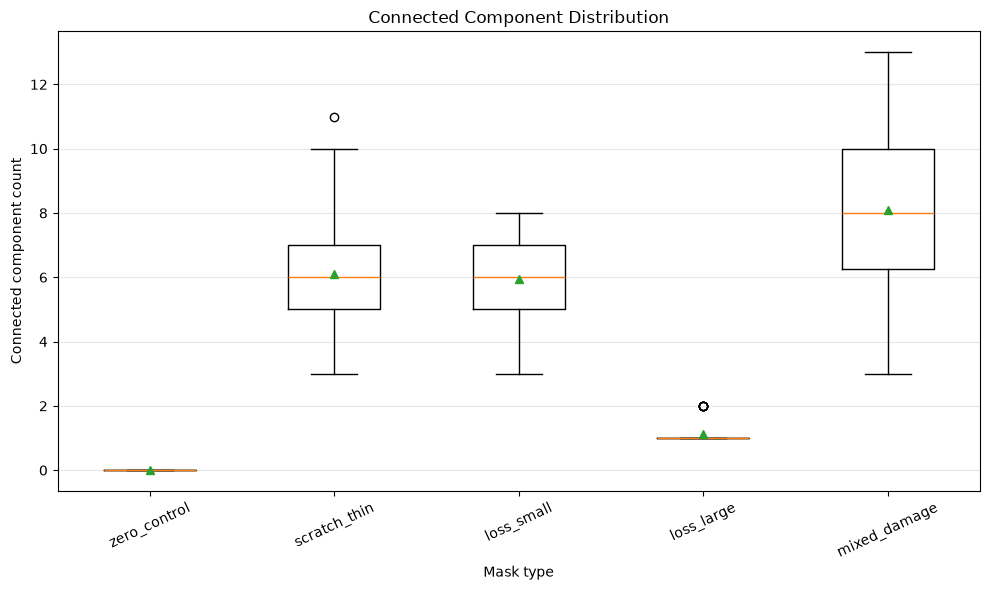

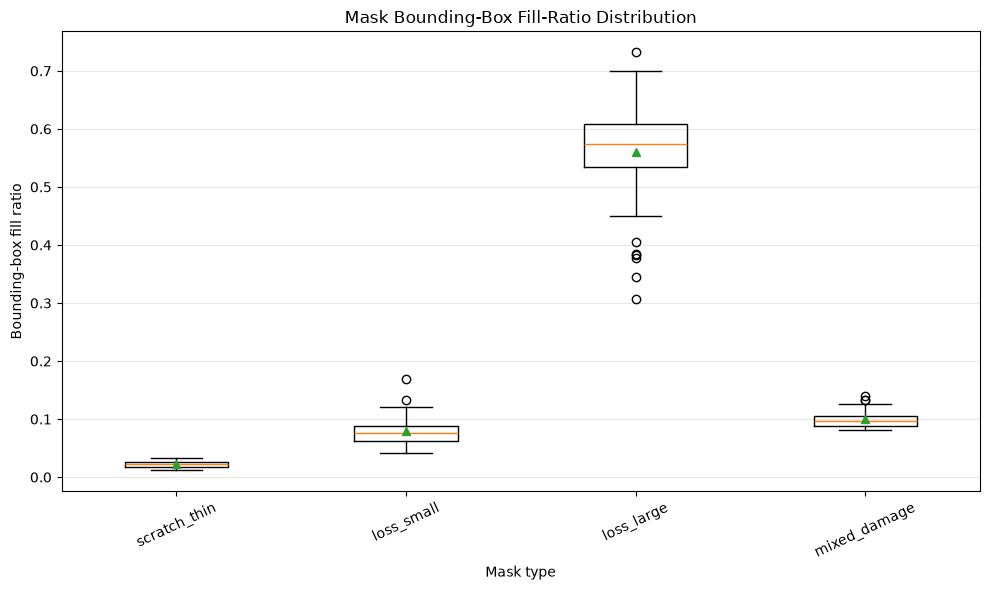

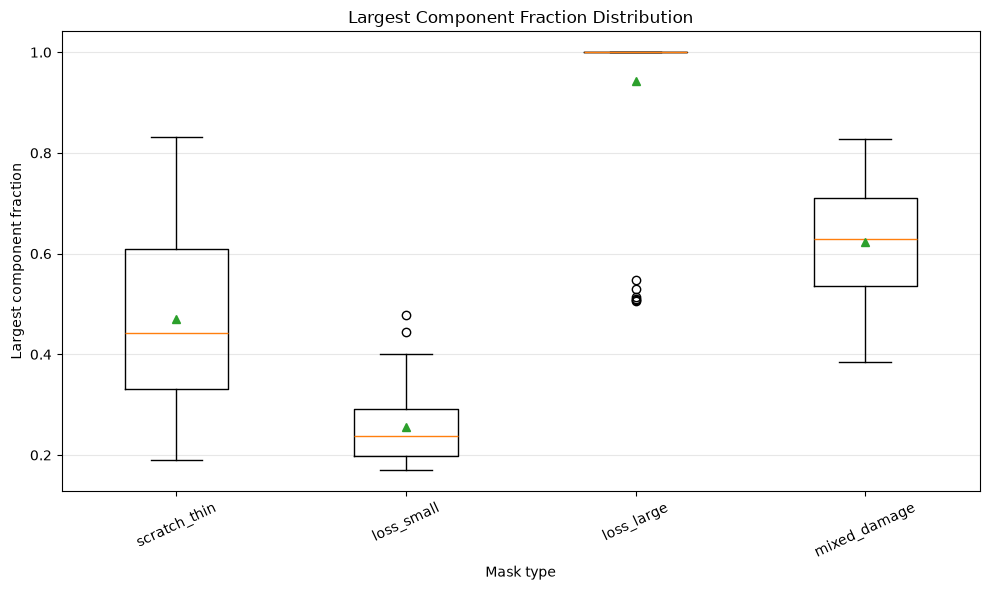

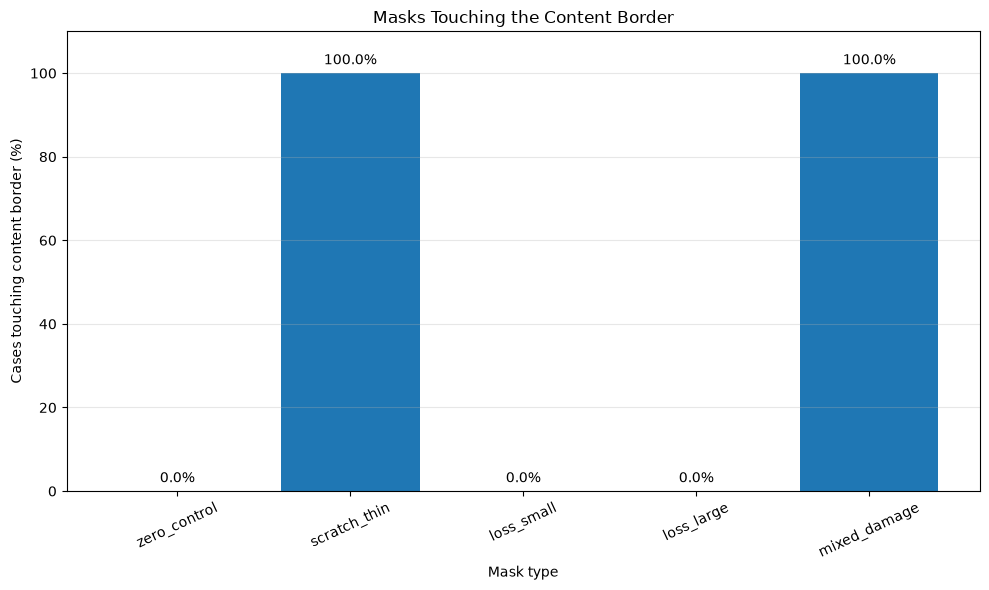

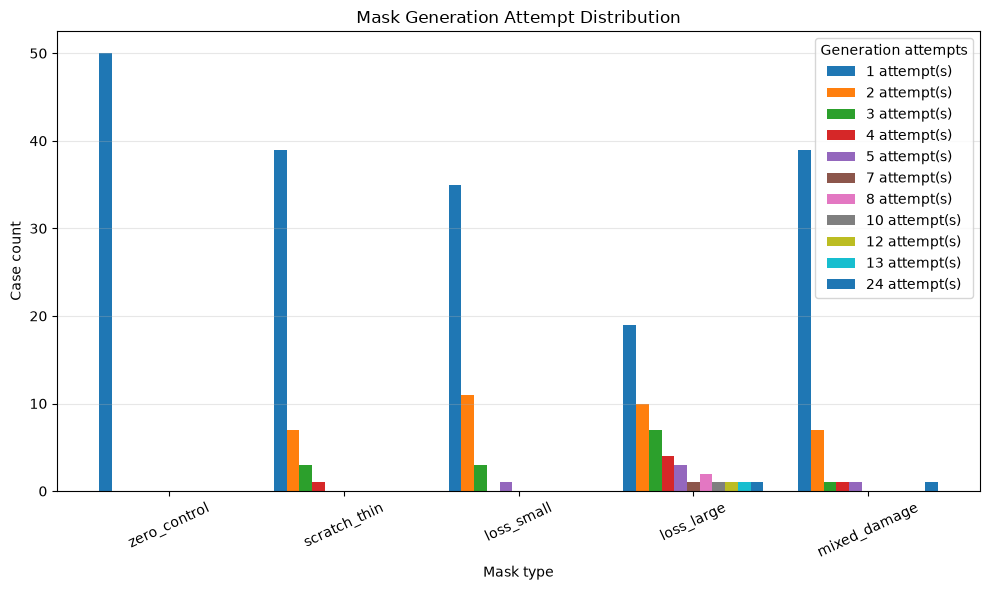

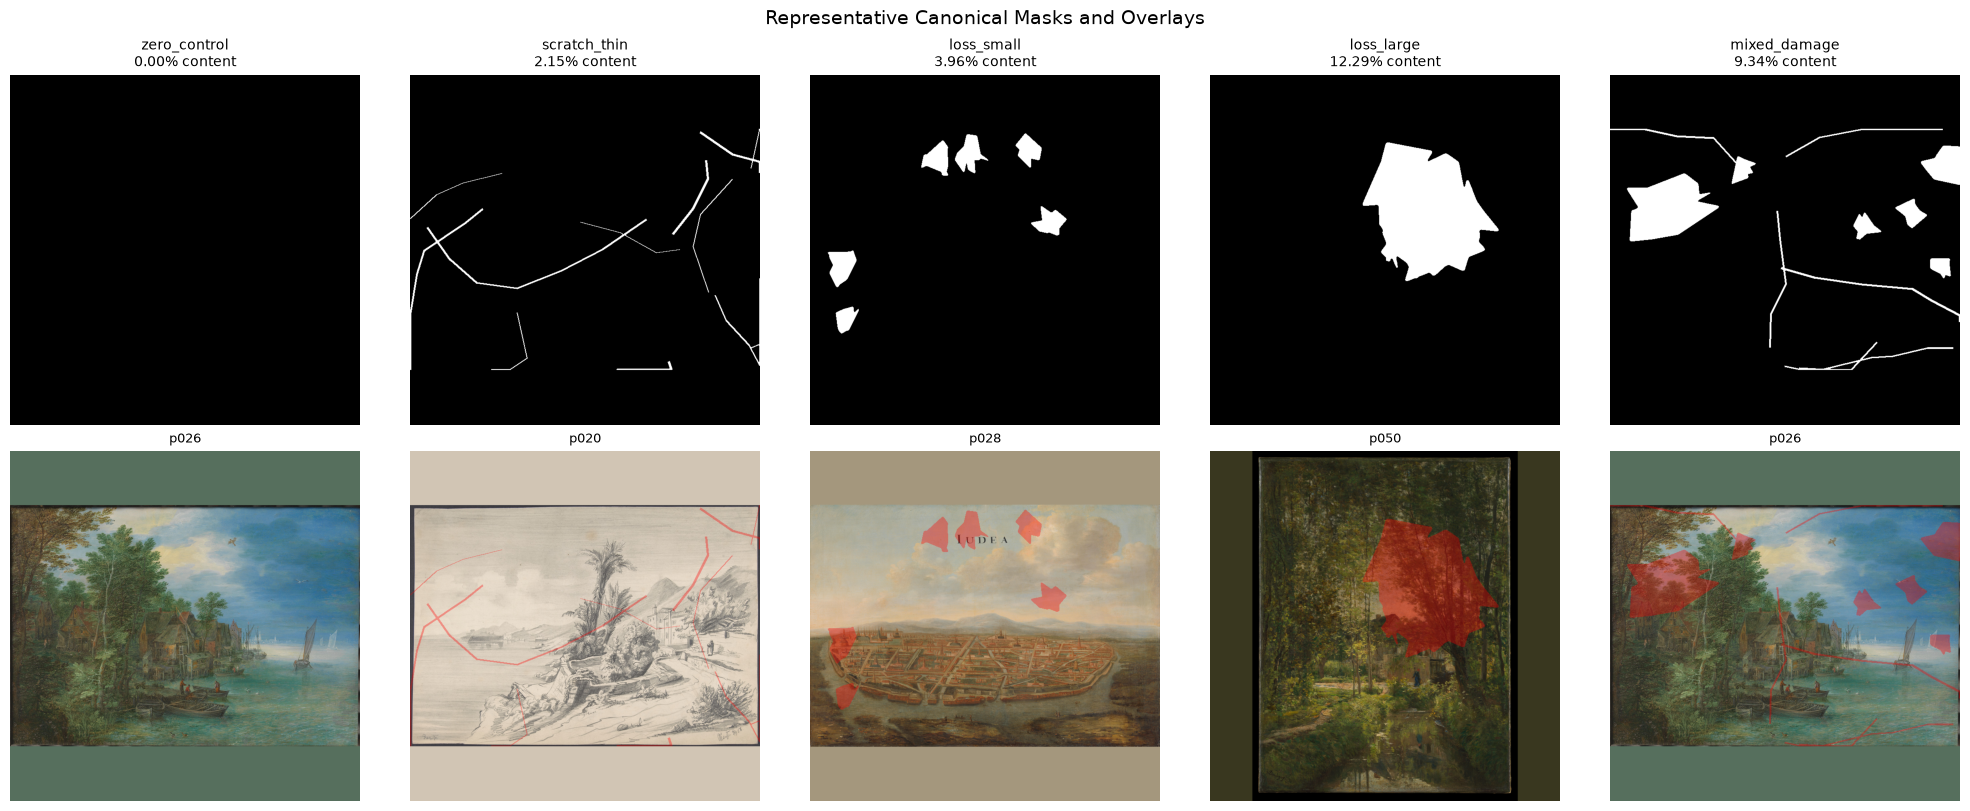

,figure_name,figure_path,exists,size_bytes
0,mask_area_percentage_distribution,outputs\figures\masks\mask_area_percentage_dis...,True,130783
1,mask_connected_component_distribution,outputs\figures\masks\mask_connected_component...,True,121601
2,mask_bbox_fill_ratio_distribution,outputs\figures\masks\mask_bbox_fill_ratio_dis...,True,132903
3,mask_largest_component_fraction_distribution,outputs\figures\masks\mask_largest_component_f...,True,124438
4,mask_border_touch_percentage,outputs\figures\masks\mask_border_touch_percen...,True,140278
5,mask_generation_attempt_distribution,outputs\figures\masks\mask_generation_attempt_...,True,195205
6,representative_mask_overlays,outputs\figures\masks\representative_mask_over...,True,5341181



All canonical mask-generation figures were created successfully.


In [15]:
# Generate and save canonical mask-generation figures

mask_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)


figure_output_paths = {
    "mask_area_percentage_distribution": (
        mask_figure_dir
        / "mask_area_percentage_distribution.png"
    ),
    "mask_connected_component_distribution": (
        mask_figure_dir
        / "mask_connected_component_distribution.png"
    ),
    "mask_bbox_fill_ratio_distribution": (
        mask_figure_dir
        / "mask_bbox_fill_ratio_distribution.png"
    ),
    "mask_largest_component_fraction_distribution": (
        mask_figure_dir
        / "mask_largest_component_fraction_distribution.png"
    ),
    "mask_border_touch_percentage": (
        mask_figure_dir
        / "mask_border_touch_percentage.png"
    ),
    "mask_generation_attempt_distribution": (
        mask_figure_dir
        / "mask_generation_attempt_distribution.png"
    ),
    "representative_mask_overlays": (
        mask_figure_dir
        / "representative_mask_overlays.png"
    ),
}


plot_mask_metadata_df = (
    mask_metadata_df.copy()
)


plot_mask_metadata_df[
    "mask_type"
] = pd.Categorical(
    plot_mask_metadata_df["mask_type"],
    categories=configured_mask_types,
    ordered=True,
)


non_zero_mask_types = [
    mask_type
    for mask_type in configured_mask_types
    if mask_type != "zero_control"
]


non_zero_mask_metadata_df = (
    plot_mask_metadata_df.loc[
        plot_mask_metadata_df[
            "mask_type"
        ].isin(non_zero_mask_types)
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Figure 1: mask area percentage distribution
# -------------------------------------------------------------------------

area_figure, area_axis = plt.subplots(
    figsize=(10, 6)
)


area_distribution_data = [
    plot_mask_metadata_df.loc[
        plot_mask_metadata_df[
            "mask_type"
        ]
        == mask_type,
        "actual_mask_area_percentage_content",
    ]
    .astype(float)
    .to_numpy()
    for mask_type in configured_mask_types
]


area_axis.boxplot(
    area_distribution_data,
    tick_labels=configured_mask_types,
    showmeans=True,
)


area_axis.set_title(
    "Mask Area Percentage Distribution"
)

area_axis.set_xlabel("Mask type")

area_axis.set_ylabel(
    "Damaged content area (%)"
)

area_axis.tick_params(
    axis="x",
    rotation=25,
)

area_axis.grid(
    axis="y",
    alpha=0.3,
)


area_figure.tight_layout()

area_figure.savefig(
    figure_output_paths[
        "mask_area_percentage_distribution"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(area_figure)


# -------------------------------------------------------------------------
# Figure 2: connected-component distribution
# -------------------------------------------------------------------------

component_figure, component_axis = plt.subplots(
    figsize=(10, 6)
)


component_distribution_data = [
    plot_mask_metadata_df.loc[
        plot_mask_metadata_df[
            "mask_type"
        ]
        == mask_type,
        "connected_component_count",
    ]
    .astype(float)
    .to_numpy()
    for mask_type in configured_mask_types
]


component_axis.boxplot(
    component_distribution_data,
    tick_labels=configured_mask_types,
    showmeans=True,
)


component_axis.set_title(
    "Connected Component Distribution"
)

component_axis.set_xlabel("Mask type")

component_axis.set_ylabel(
    "Connected component count"
)

component_axis.tick_params(
    axis="x",
    rotation=25,
)

component_axis.grid(
    axis="y",
    alpha=0.3,
)


component_figure.tight_layout()

component_figure.savefig(
    figure_output_paths[
        "mask_connected_component_distribution"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(component_figure)


# -------------------------------------------------------------------------
# Figure 3: bounding-box fill-ratio distribution
# -------------------------------------------------------------------------

bbox_figure, bbox_axis = plt.subplots(
    figsize=(10, 6)
)


bbox_distribution_data = [
    non_zero_mask_metadata_df.loc[
        non_zero_mask_metadata_df[
            "mask_type"
        ]
        == mask_type,
        "bbox_fill_ratio",
    ]
    .dropna()
    .astype(float)
    .to_numpy()
    for mask_type in non_zero_mask_types
]


bbox_axis.boxplot(
    bbox_distribution_data,
    tick_labels=non_zero_mask_types,
    showmeans=True,
)


bbox_axis.set_title(
    "Mask Bounding-Box Fill-Ratio Distribution"
)

bbox_axis.set_xlabel("Mask type")

bbox_axis.set_ylabel(
    "Bounding-box fill ratio"
)

bbox_axis.tick_params(
    axis="x",
    rotation=25,
)

bbox_axis.grid(
    axis="y",
    alpha=0.3,
)


bbox_figure.tight_layout()

bbox_figure.savefig(
    figure_output_paths[
        "mask_bbox_fill_ratio_distribution"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(bbox_figure)


# -------------------------------------------------------------------------
# Figure 4: largest-component fraction distribution
# -------------------------------------------------------------------------

largest_component_figure, largest_component_axis = (
    plt.subplots(
        figsize=(10, 6)
    )
)


largest_component_distribution_data = [
    non_zero_mask_metadata_df.loc[
        non_zero_mask_metadata_df[
            "mask_type"
        ]
        == mask_type,
        "largest_component_fraction",
    ]
    .dropna()
    .astype(float)
    .to_numpy()
    for mask_type in non_zero_mask_types
]


largest_component_axis.boxplot(
    largest_component_distribution_data,
    tick_labels=non_zero_mask_types,
    showmeans=True,
)


largest_component_axis.set_title(
    "Largest Component Fraction Distribution"
)

largest_component_axis.set_xlabel(
    "Mask type"
)

largest_component_axis.set_ylabel(
    "Largest component fraction"
)

largest_component_axis.tick_params(
    axis="x",
    rotation=25,
)

largest_component_axis.grid(
    axis="y",
    alpha=0.3,
)


largest_component_figure.tight_layout()

largest_component_figure.savefig(
    figure_output_paths[
        "mask_largest_component_fraction_distribution"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(largest_component_figure)


# -------------------------------------------------------------------------
# Figure 5: border-touch percentage
# -------------------------------------------------------------------------

border_plot_df = (
    mask_border_summary_df
    .set_index("mask_type")
    .reindex(configured_mask_types)
    .reset_index()
)


border_figure, border_axis = plt.subplots(
    figsize=(10, 6)
)


border_axis.bar(
    border_plot_df["mask_type"],
    border_plot_df[
        "border_touch_percentage"
    ],
)


border_axis.set_title(
    "Masks Touching the Content Border"
)

border_axis.set_xlabel("Mask type")

border_axis.set_ylabel(
    "Cases touching content border (%)"
)

border_axis.set_ylim(
    0,
    max(
        100.0,
        float(
            border_plot_df[
                "border_touch_percentage"
            ].max()
        )
        * 1.1,
    ),
)

border_axis.tick_params(
    axis="x",
    rotation=25,
)

border_axis.grid(
    axis="y",
    alpha=0.3,
)


for bar, percentage in zip(
    border_axis.patches,
    border_plot_df[
        "border_touch_percentage"
    ],
):
    border_axis.annotate(
        f"{percentage:.1f}%",
        (
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
        ),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
    )


border_figure.tight_layout()

border_figure.savefig(
    figure_output_paths[
        "mask_border_touch_percentage"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(border_figure)


# -------------------------------------------------------------------------
# Figure 6: generation-attempt distribution
# -------------------------------------------------------------------------

attempt_figure, attempt_axis = plt.subplots(
    figsize=(10, 6)
)


attempt_counts_df = (
    plot_mask_metadata_df
    .groupby(
        [
            "mask_type",
            "generation_attempts",
        ],
        observed=True,
    )
    .size()
    .rename("case_count")
    .reset_index()
)


attempt_values = sorted(
    attempt_counts_df[
        "generation_attempts"
    ]
    .astype(int)
    .unique()
    .tolist()
)


x_positions = np.arange(
    len(configured_mask_types)
)


bar_width = (
    0.8 / max(len(attempt_values), 1)
)


for attempt_index, attempt_value in enumerate(
    attempt_values
):
    attempt_series = (
        attempt_counts_df.loc[
            attempt_counts_df[
                "generation_attempts"
            ].astype(int)
            == attempt_value
        ]
        .set_index("mask_type")[
            "case_count"
        ]
        .reindex(
            configured_mask_types,
            fill_value=0,
        )
    )

    offset = (
        attempt_index
        - (len(attempt_values) - 1) / 2
    ) * bar_width

    attempt_axis.bar(
        x_positions + offset,
        attempt_series.to_numpy(),
        width=bar_width,
        label=f"{attempt_value} attempt(s)",
    )


attempt_axis.set_title(
    "Mask Generation Attempt Distribution"
)

attempt_axis.set_xlabel("Mask type")

attempt_axis.set_ylabel("Case count")

attempt_axis.set_xticks(x_positions)

attempt_axis.set_xticklabels(
    configured_mask_types,
    rotation=25,
)

attempt_axis.grid(
    axis="y",
    alpha=0.3,
)

attempt_axis.legend(
    title="Generation attempts"
)


attempt_figure.tight_layout()

attempt_figure.savefig(
    figure_output_paths[
        "mask_generation_attempt_distribution"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(attempt_figure)


# -------------------------------------------------------------------------
# Figure 7: representative mask overlays
# -------------------------------------------------------------------------

representative_mask_rows = []


for mask_type in configured_mask_types:
    mask_type_rows_df = (
        mask_metadata_df.loc[
            mask_metadata_df[
                "mask_type"
            ]
            == mask_type
        ]
        .sort_values(
            [
                "actual_mask_area_percentage_content",
                "painting_id",
            ],
            kind="stable",
        )
        .reset_index(drop=True)
    )


    if mask_type_rows_df.empty:
        raise RuntimeError(
            "No masks were found for configured "
            f"mask type: {mask_type}"
        )


    representative_row_index = (
        len(mask_type_rows_df) // 2
    )

    representative_mask_rows.append(
        mask_type_rows_df.iloc[
            representative_row_index
        ]
    )


representative_masks_df = pd.DataFrame(
    representative_mask_rows
)


representative_figure, representative_axes = (
    plt.subplots(
        2,
        len(configured_mask_types),
        figsize=(
            4 * len(configured_mask_types),
            8,
        ),
        constrained_layout=True,
    )
)


for column_index, representative_row in (
    representative_masks_df
    .reset_index(drop=True)
    .iterrows()
):
    representative_painting_id = str(
        representative_row[
            "painting_id"
        ]
    )


    processed_row_matches_df = (
        processed_metadata_df.loc[
            processed_metadata_df[
                "painting_id"
            ].astype(str)
            == representative_painting_id
        ]
    )


    if len(processed_row_matches_df) != 1:
        raise RuntimeError(
            "Expected exactly one processed metadata row "
            f"for painting {representative_painting_id}, "
            f"found {len(processed_row_matches_df)}."
        )


    processed_row = (
        processed_row_matches_df.iloc[0]
    )


    processed_image_path = Path(
        str(
            processed_row[
                "processed_path"
            ]
        )
    )


    if not processed_image_path.is_absolute():
        processed_image_path = (
            PROJECT_ROOT
            / processed_image_path
        )


    representative_mask_path = Path(
        str(
            representative_row[
                "mask_path"
            ]
        )
    )


    if not representative_mask_path.is_absolute():
        representative_mask_path = (
            PROJECT_ROOT
            / representative_mask_path
        )


    if not processed_image_path.exists():
        raise FileNotFoundError(
            "Representative processed image "
            f"not found: {processed_image_path}"
        )


    if not representative_mask_path.exists():
        raise FileNotFoundError(
            "Representative mask not found: "
            f"{representative_mask_path}"
        )


    with Image.open(
        processed_image_path
    ) as opened_processed_image:
        representative_clean_array = (
            np.asarray(
                opened_processed_image
                .convert("RGB")
            )
        )


    with Image.open(
        representative_mask_path
    ) as opened_representative_mask:
        representative_mask_array = (
            np.asarray(
                opened_representative_mask
                .convert("L")
            )
        )


    representative_overlay_array = (
        representative_clean_array.copy()
    )


    representative_overlay_array[
        representative_mask_array > 0
    ] = [
        255,
        0,
        0,
    ]


    representative_blended_array = (
        0.65
        * representative_clean_array
        + 0.35
        * representative_overlay_array
    ).astype(np.uint8)


    representative_axes[
        0,
        column_index,
    ].imshow(
        representative_mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    representative_axes[
        0,
        column_index,
    ].set_title(
        f"{representative_row['mask_type']}\n"
        f"{representative_row['actual_mask_area_percentage_content']:.2f}% content",
        fontsize=10,
    )

    representative_axes[
        0,
        column_index,
    ].axis("off")


    representative_axes[
        1,
        column_index,
    ].imshow(
        representative_blended_array
    )

    representative_axes[
        1,
        column_index,
    ].set_title(
        representative_painting_id,
        fontsize=9,
    )

    representative_axes[
        1,
        column_index,
    ].axis("off")


representative_figure.suptitle(
    "Representative Canonical Masks and Overlays",
    fontsize=14,
)


representative_figure.savefig(
    figure_output_paths[
        "representative_mask_overlays"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(representative_figure)


# -------------------------------------------------------------------------
# Verify all canonical figures
# -------------------------------------------------------------------------

figure_manifest_records = []


for figure_name, figure_path in (
    figure_output_paths.items()
):
    figure_exists = figure_path.exists()

    figure_size_bytes = (
        figure_path.stat().st_size
        if figure_exists
        else 0
    )

    figure_manifest_records.append(
        {
            "figure_name": figure_name,
            "figure_path": str(
                figure_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": figure_exists,
            "size_bytes": figure_size_bytes,
        }
    )


mask_figure_manifest_df = pd.DataFrame(
    figure_manifest_records
)


display(mask_figure_manifest_df)


if not (
    mask_figure_manifest_df[
        "exists"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "One or more canonical figures "
        "were not created."
    )


if (
    mask_figure_manifest_df[
        "size_bytes"
    ]
    .astype(int)
    .le(0)
    .any()
):
    raise RuntimeError(
        "One or more canonical figures "
        "are empty."
    )


print(
    "\nAll canonical mask-generation "
    "figures were created successfully."
)

In [16]:
# Generate canonical report artifacts

import json
from datetime import datetime
from textwrap import dedent


report_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)


report_timestamp = datetime.now().isoformat()


mask_generation_manifest = {
    "stage": "03_mask_generation",
    "generated_at": report_timestamp,
    "experiment_name": experiment_name,
    "experiment_version": experiment_version,
    "generator_name": generator_name,
    "generator_version": generator_version,
    "config_version": config_version,
    "painting_count": int(
        len(processed_metadata_df)
    ),
    "configured_mask_types": configured_mask_types,
    "expected_masks": int(
        expected_mask_count
    ),
    "generated_masks": int(
        len(mask_metadata_df)
    ),
    "validation_passed": bool(
        mask_validation_df[
            "validation_passed"
        ]
        .astype(bool)
        .all()
    ),
    "figures": {
        row.figure_name: row.figure_path
        for row in mask_figure_manifest_df.itertuples()
    },
}


with open(
    mask_manifest_path,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        mask_generation_manifest,
        output_file,
        indent=4,
    )


report_text = dedent(
    f"""
    # Mask Generation Report

    ## Experiment

    - Experiment: {experiment_name}
    - Version: {experiment_version}
    - Generator: {generator_name}
    - Generator version: {generator_version}
    - Config version: {config_version}

    ## Dataset

    - Paintings: {len(processed_metadata_df)}
    - Mask types: {len(configured_mask_types)}
    - Expected masks: {expected_mask_count}
    - Generated masks: {len(mask_metadata_df)}

    ## Validation

    - Metadata validation: PASS
    - Saved-mask validation: PASS
    - Inventory validation: PASS
    - Deterministic replay: PASS

    ## Output artifacts

    Metadata:
    - {mask_metadata_path.relative_to(PROJECT_ROOT)}

    Audit:
    - {mask_generation_audit_path.relative_to(PROJECT_ROOT)}

    Figures:
    """
).strip()


for row in mask_figure_manifest_df.itertuples():
    report_text += (
        f"\n- {row.figure_path}"
    )


with open(
    mask_report_path,
    "w",
    encoding="utf-8",
) as output_file:
    output_file.write(report_text)


print("Generated report artifacts")
print("--------------------------")
print(mask_manifest_path)
print(mask_report_path)

Generated report artifacts
--------------------------
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\mask_generation_metadata.json
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\mask_generation_report.md


In [17]:
# Final notebook audit

required_artifacts = [
    mask_metadata_path,
    mask_generation_audit_path,
    mask_manifest_path,
    mask_report_path,
]


required_artifacts.extend(
    [
        Path(row.figure_path)
        if Path(row.figure_path).is_absolute()
        else PROJECT_ROOT / row.figure_path
        for row in mask_figure_manifest_df.itertuples()
    ]
)


artifact_records = []


for artifact_path in required_artifacts:
    artifact_records.append(
        {
            "artifact": str(
                artifact_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else 0
            ),
        }
    )


final_audit_df = pd.DataFrame(
    artifact_records
)


display(final_audit_df)


missing_artifacts_df = (
    final_audit_df.loc[
        ~final_audit_df["exists"]
    ]
)


if not missing_artifacts_df.empty:
    display(missing_artifacts_df)
    raise RuntimeError(
        "Required notebook artifacts are missing."
    )


empty_artifacts_df = (
    final_audit_df.loc[
        final_audit_df[
            "size_bytes"
        ]
        <= 0
    ]
)


if not empty_artifacts_df.empty:
    display(empty_artifacts_df)
    raise RuntimeError(
        "One or more notebook artifacts are empty."
    )


print("\nNotebook 03 final audit passed.")

print(
    f"\nGenerated {expected_mask_count} masks "
    f"across {len(configured_mask_types)} mask types."
)

print(
    "All canonical artifacts verified."
)

,artifact,exists,size_bytes
0,data\processed\metadata\metadata_masks.csv,True,139074
1,outputs\03_mask_generation\mask_generation_aud...,True,181
2,outputs\reports\mask_generation_metadata.json,True,1411
3,outputs\reports\mask_generation_report.md,True,1052
4,outputs\figures\masks\mask_area_percentage_dis...,True,130783
5,outputs\figures\masks\mask_connected_component...,True,121601
6,outputs\figures\masks\mask_bbox_fill_ratio_dis...,True,132903
7,outputs\figures\masks\mask_largest_component_f...,True,124438
8,outputs\figures\masks\mask_border_touch_percen...,True,140278
9,outputs\figures\masks\mask_generation_attempt_...,True,195205



Notebook 03 final audit passed.

Generated 250 masks across 5 mask types.
All canonical artifacts verified.


# Notebook Complete

## Outputs

### Canonical dataset

- `data/processed/masks/*.png`
- `data/processed/metadata/metadata_masks.csv`

### Audit

- `outputs/03_mask_generation/mask_generation_audit.csv`

### Figures

- `outputs/figures/masks/`

### Reports

- `outputs/reports/mask_generation_metadata.json`
- `outputs/reports/mask_generation_report.md`

## Validation completed

- Configuration validation
- Processed metadata validation
- Generator implementation validation
- Deterministic replay validation
- Binary-mask validation
- Content-region validation
- Padding-overlap validation
- Saved-file validation
- Inventory validation
- Artifact validation

The generated mask dataset is the canonical input for Notebook 04 (Damaged Image Generation).